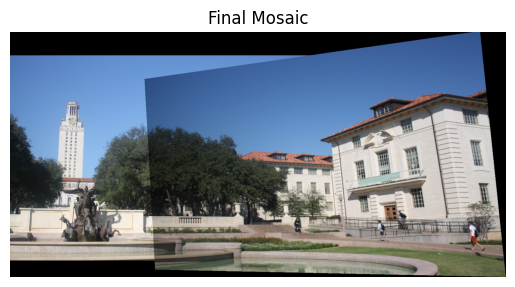

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. SIFT + MATCHING (from 1.1)
def get_correspondences(img1, img2, num_matches=50):
    sift = cv2.SIFT_create()

    #kp = keypoints, des = descriptors
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    good = sorted(good, key=lambda x: x.distance)[:num_matches]

    # pts1[i] corresponds to pts2[i]
    # we extract the (x, y) coordinates from the keypoints using the indices from the good matches
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

    return pts1, pts2



# 2. HOMOGRAPHY (from 1.2)

def compute_homography(pts1, pts2):
    n = pts1.shape[0]
    A = []

    for i in range(n):
        x, y = pts1[i]
        xp, yp = pts2[i]

        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A)

    # Solve using SVD
    U, S, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    return H / H[2, 2]



# 3. FORWARD WARP (REQUIRED)
def forward_warp(img, H, out_shape):
    h_out, w_out = out_shape
    warped = np.zeros((h_out, w_out, 3), dtype=np.uint8)

    h, w = img.shape[:2]

    for y in range(h):
        for x in range(w):
            pt = np.array([x, y, 1])
            pt_p = H @ pt
            pt_p /= pt_p[2]

            x_p, y_p = int(pt_p[0]), int(pt_p[1])

            if 0 <= x_p < w_out and 0 <= y_p < h_out:
                warped[y_p, x_p] = img[y, x]

    return warped


# 4. BILINEAR INTERPOLATION

def bilinear(img, x, y):
    h, w = img.shape[:2]

    if x < 0 or x >= w-1 or y < 0 or y >= h-1:
        return np.array([0, 0, 0])

    x0, y0 = int(x), int(y)
    dx, dy = x - x0, y - y0

    val = (
        (1-dx)*(1-dy)*img[y0, x0] +
        dx*(1-dy)*img[y0, x0+1] +
        (1-dx)*dy*img[y0+1, x0] +
        dx*dy*img[y0+1, x0+1]
    )

    return val



# 5. INVERSE WARP (MAIN)

def inverse_warp(img, H_inv, out_shape):
    h_out, w_out = out_shape
    warped = np.zeros((h_out, w_out, 3), dtype=np.uint8)

    for y in range(h_out):
        for x in range(w_out):
            pt = np.array([x, y, 1])
            pt_src = H_inv @ pt
            pt_src /= pt_src[2]

            xs, ys = pt_src[0], pt_src[1]

            if 0 <= xs < img.shape[1] and 0 <= ys < img.shape[0]:
                warped[y, x] = bilinear(img, xs, ys)

    return warped


# 6. COMPUTE CANVAS SIZE

def get_canvas_size(img1, img2, H):
    h1, w1 = img1.shape[:2]

    corners = np.array([
        [0, 0, 1],
        [w1, 0, 1],
        [0, h1, 1],
        [w1, h1, 1]
    ]).T

    warped_corners = H @ corners
    warped_corners /= warped_corners[2]

    all_x = np.concatenate((warped_corners[0], [0, img2.shape[1]]))
    all_y = np.concatenate((warped_corners[1], [0, img2.shape[0]]))

    xmin, xmax = int(np.min(all_x)), int(np.max(all_x))
    ymin, ymax = int(np.min(all_y)), int(np.max(all_y))

    tx, ty = -xmin, -ymin

    width = xmax - xmin
    height = ymax - ymin

    return width, height, tx, ty



# 7. CREATE MOSAIC

def create_mosaic(img1, img2, H):
    width, height, tx, ty = get_canvas_size(img1, img2, H)

    # translation matrix
    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

    H_total = T @ H
    H_inv = np.linalg.inv(H_total)

    warped = inverse_warp(img1, H_inv, (height, width))

    canvas = np.zeros((height, width, 3), dtype=np.uint8)

    # place img2
    canvas[ty:ty+img2.shape[0], tx:tx+img2.shape[1]] = img2

    # overlay warped image
    mask = (warped > 0)
    canvas[mask] = warped[mask]

    return canvas



#  MAIN


#import os

#print("Current directory:", os.getcwd())

img1 = cv2.imread("assignment_2_materials/pano_image1.jpg")
img2 = cv2.imread("assignment_2_materials/pano_image2.jpg")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

pts1, pts2 = get_correspondences(img1, img2)

H = compute_homography(pts1, pts2)
mosaic = create_mosaic(img1, img2, H)

plt.imshow(mosaic)
plt.title("Final Mosaic")
plt.axis("off")
plt.show()